In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [8]:
# Style of graphs
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [9]:
# Load clean data
df = pd.read_csv('../data/cleaned/startups_clean.csv',
                 parse_dates=['founded_at','first_funding_at','last_funding_at'])

In [10]:
# 3 subsets — use the right one per question
df_full  = df.copy() 
# Q1 Q2 Q3 Q5 — all 66,343 rows
df_dated = df[df['has_founded_date']].copy()
# Q6 Q7 — 51,125 rows with date
df_q4    = df[df['funding_total_usd'].notna()].copy()
# Q4 — 53,559 rows with funding


In [11]:
print(f"df_full: {len(df_full):,} | df_dated: {len(df_dated):,} | df_q4: {len(df_q4):,}")

df_full: 66,343 | df_dated: 51,125 | df_q4: 66,343


In [12]:
# Q1 — Failure rate by primary category (top 15 categories)
cat_stats = (
    df_full.groupby('primary_category')['is_failed']
    .agg(['sum', 'count'])
    .rename(columns={'sum':'failed','count':'total'})
)
cat_stats['failure_rate'] = (cat_stats['failed'] / cat_stats['total'] * 100).round(1)
cat_stats = cat_stats[cat_stats['total'] >= 50] # min 50 startups per category
top15 = cat_stats.nlargest(15, 'failure_rate')


In [13]:
print(top15[['failed','total','failure_rate']])

                       failed  total  failure_rate
primary_category                                  
Unknown                   953   3147          30.3
Coupons                    19     88          21.6
Facebook Applications      19     95          20.0
Curated Web               415   2196          18.9
Services                   37    198          18.7
Application Platforms      42    229          18.3
Development Platforms      11     62          17.7
Public Relations           33    188          17.6
Delivery                   21    136          15.4
Search                     28    185          15.1
Employment                  9     60          15.0
Messaging                  40    273          14.7
Cars                       11     77          14.3
Business Services          57    401          14.2
Music                      36    257          14.0


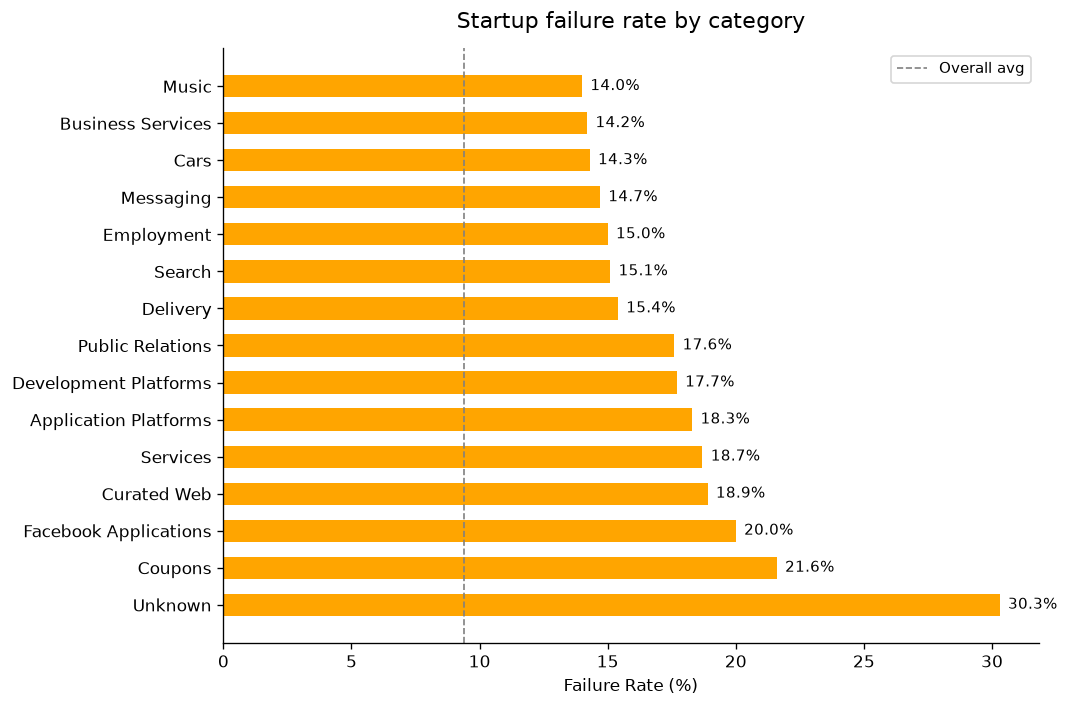

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15['failure_rate'], color="orange", height=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=9)
ax.set_xlabel('Failure Rate (%)')
ax.set_title('Startup failure rate by category', fontsize=13, pad=12)
ax.axvline(df_full['is_failed'].mean()*100, color='gray', ls='--', lw=1, label='Overall avg')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/q1_category_failure_rate.png', dpi=150)
plt.show()




In [15]:
# Q2 — Failure rate by country (top 15 by startup count)
country_stats = (
    df_full.groupby('country_code')['is_failed']
    .agg(['sum','count'])
    .rename(columns={'sum':'failed','count':'total'})
)
country_stats['failure_rate'] = (country_stats['failed']/country_stats['total']*100).round(1)
top_countries = country_stats[country_stats['total'] >= 100].nlargest(15,'failure_rate')

In [16]:
print(top_countries[['failed','total','failure_rate']])

              failed  total  failure_rate
country_code                             
RUS              169    458          36.9
UNKNOWN         1651   6956          23.7
BRA               58    445          13.0
SWE               48    452          10.6
AUT               14    133          10.5
MEX               15    145          10.3
ARG               19    186          10.2
AUS               45    503           8.9
IDN                9    108           8.3
CAN              158   1925           8.2
NOR               11    134           8.2
DNK               25    311           8.0
FRA               91   1135           8.0
ISR               77    964           8.0
ESP               58    745           7.8


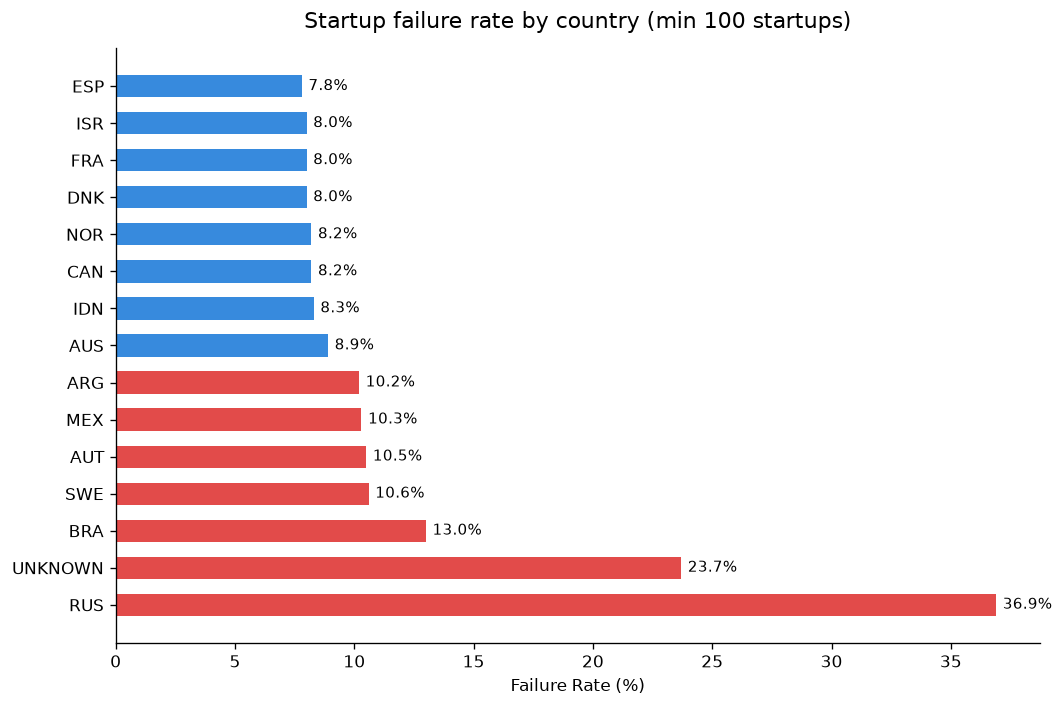

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E24B4A' if r > 10 else '#378ADD' for r in top_countries['failure_rate']]
bars = ax.barh(top_countries.index, top_countries['failure_rate'], color=colors, height=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('Failure Rate (%)')
ax.set_title('Startup failure rate by country (min 100 startups)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/q2_country_failure_rate.png', dpi=150)
plt.show()

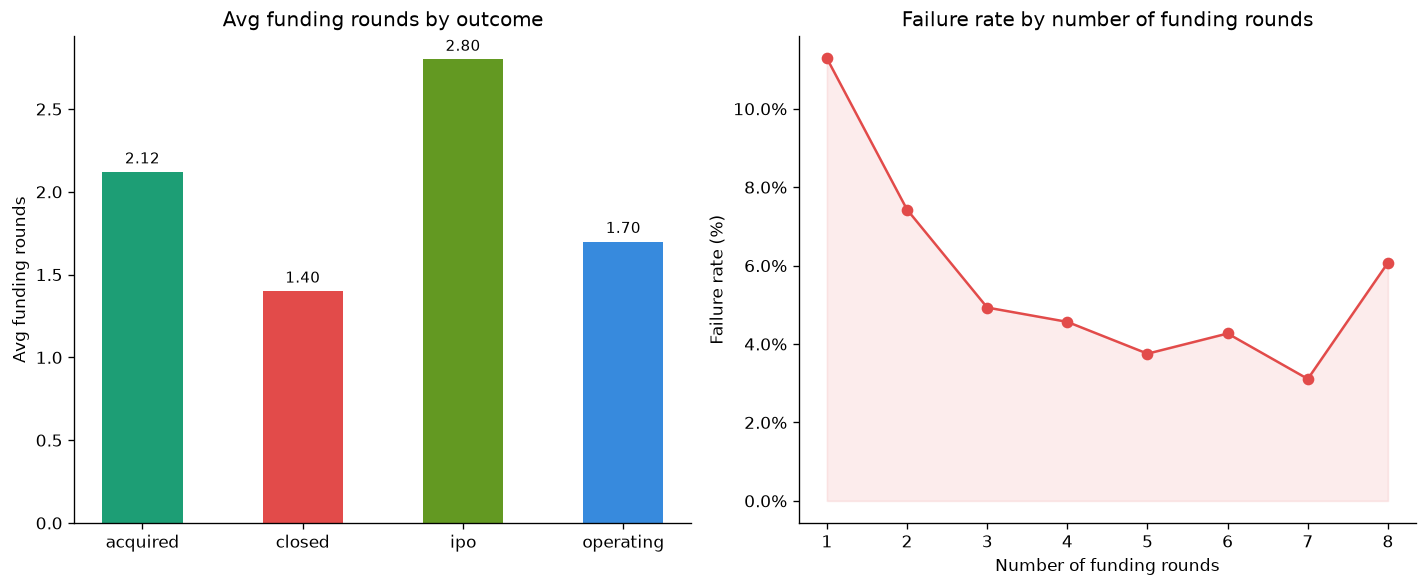

In [18]:
# Q3 — Avg funding rounds by status + failure rate by rounds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: avg rounds per status
avg_rounds = df_full.groupby('status')['funding_rounds'].mean().round(2)
colors_map = {'closed':'#E24B4A','operating':'#378ADD',
              'acquired':'#1D9E75','ipo':'#639922'}
bars1 = ax1.bar(avg_rounds.index,avg_rounds.values,
               color=[colors_map[s] for s in avg_rounds.index], width=0.5)
ax1.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax1.set_title('Avg funding rounds by outcome', fontsize=12)
ax1.set_ylabel('Avg funding rounds')

# Right: failure rate by number of rounds (1-8)
df_full['is_failed']= (df_full['status']=='closed').astype(int)
rounds_fail=df_full[df_full['funding_rounds']<=8].groupby('funding_rounds')['is_failed'].mean()*100
ax2.plot(rounds_fail.index, rounds_fail.values, marker='o', color='#E24B4A')
ax2.fill_between(rounds_fail.index, rounds_fail.values, color='#E24B4A', alpha=0.1)
ax2.set_title('Failure rate by number of funding rounds', fontsize=12)
ax2.set_xlabel('Number of funding rounds')
ax2.set_ylabel('Failure rate (%)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../reports/q3_rounds_failure_rate.png', dpi=150)
plt.show()


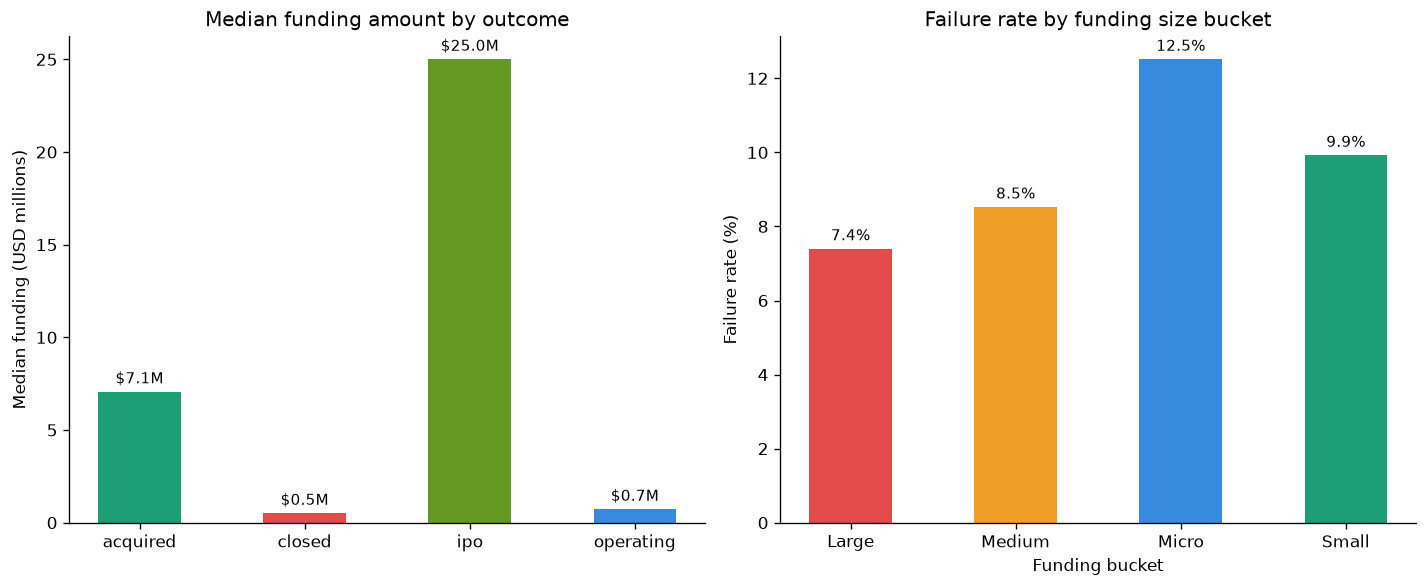

In [24]:
# Q4 — Median funding by status + failure rate by funding bucket
fig,(ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))

# Left: median funding per status
med_funding = df_q4.groupby('status')['funding_total_usd'].median()/1_000_000
bars1 = ax1.bar(med_funding.index, med_funding.values,
               color=[colors_map[s] for s in med_funding.index], width=0.5)
ax1.bar_label(bars1, fmt='$%.1fM', padding=3, fontsize=9)
ax1.set_title('Median funding amount by outcome', fontsize=12)
ax1.set_ylabel('Median funding (USD millions)')

# Right: failure rate by funding bucket
bucket_fail = (df_q4.groupby('funding_bucket', observed=True)['is_failed']
               .mean() * 100)
bucket_colors = ['#E24B4A','#EF9F27','#378ADD','#1D9E75']
bars2 = ax2.bar(bucket_fail.index, bucket_fail.values, color=bucket_colors, width=0.5)
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax2.set_title('Failure rate by funding size bucket', fontsize=12)
ax2.set_xlabel('Funding bucket')
ax2.set_ylabel('Failure rate (%)')

plt.tight_layout()
plt.savefig('../reports/q4_funding_amount_vs_survival.png', dpi=150)
plt.show()

In [26]:
# Q5 — Top 15 cities by total failed startups
city_fail = (
    df_full[df_full['city'] != 'Unknown']
    .groupby('city')['is_failed']
    .agg(['sum','count'])
    .rename(columns={'sum':'failed','count':'total'})
)
city_fail['failure_rate'] = (city_fail['failed']/city_fail['total']*100).round(1)
top_cities = city_fail[city_fail['total']>=50].nlargest(15,'failed')



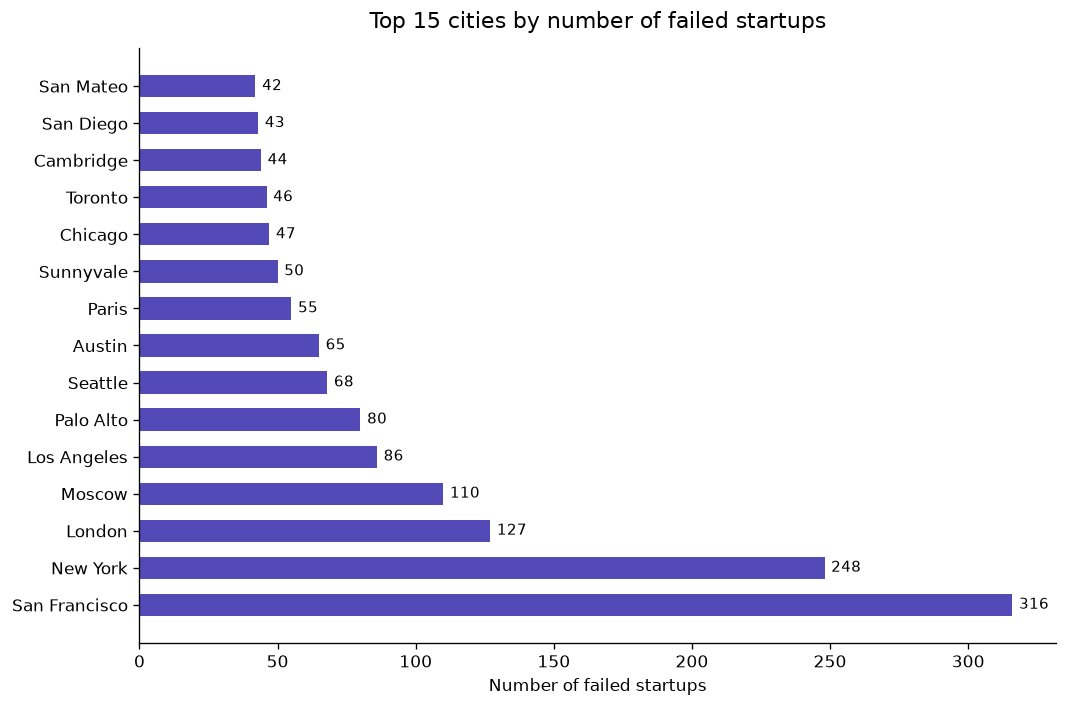

In [27]:
fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(top_cities.index, top_cities['failed'], color='#534AB7', height=0.6)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Number of failed startups')
ax.set_title('Top 15 cities by number of failed startups', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/q5_city_failures.png', dpi=150)
plt.show()

In [30]:
# Q6 — Survival years distribution for failed startups
failed_dated = df_dated[df_dated['status']=='closed']
failed_clean = failed_dated[failed_dated['survival_years'].notna() &
                            (failed_dated['survival_years'] >= 0) &
                            (failed_dated['survival_years'] <= 20)]



Text(0, 0.5, 'Median years')

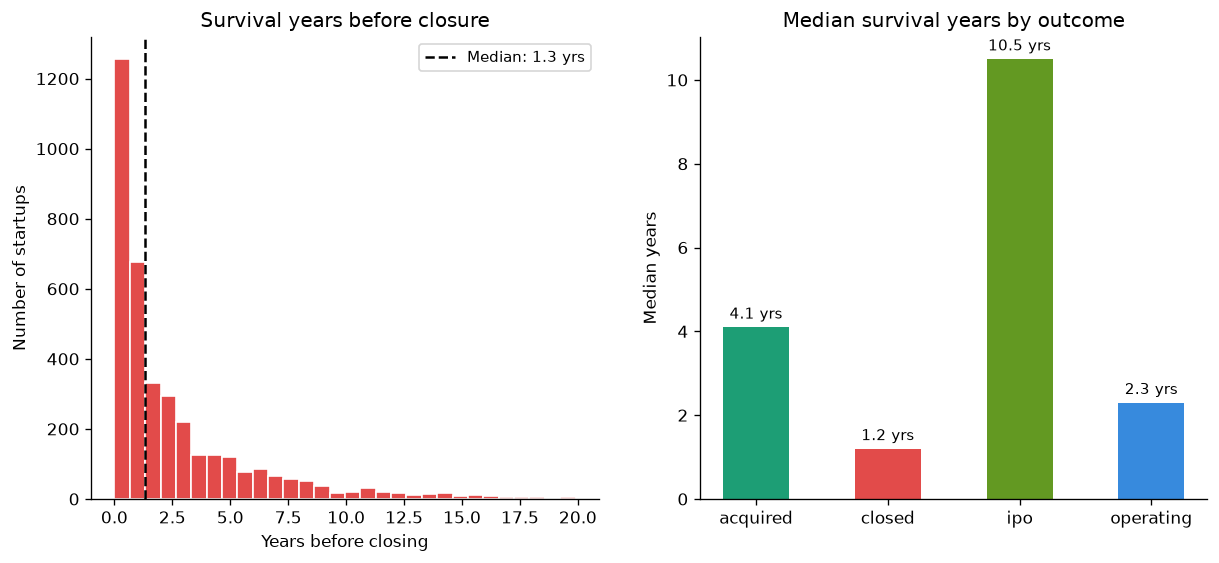

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of survival years for failed startups
ax1.hist(failed_clean['survival_years'], bins=30, color='#E24B4A', edgecolor='white')
ax1.axvline(failed_clean['survival_years'].median(), color='black',
            ls='--', lw=1.5, label=f"Median: {failed_clean['survival_years'].median():.1f} yrs")
ax1.set_title('Survival years before closure', fontsize=12)
ax1.set_xlabel('Years before closing')
ax1.set_ylabel('Number of startups')
ax1.legend(fontsize=9)

# Right: median survival years by status
med_surv = (df_dated[df_dated['survival_years'].notna()]
            .groupby('status')['survival_years'].median().round(1))
bars2 = ax2.bar(med_surv.index, med_surv.values,
               color=[colors_map[s] for s in med_surv.index], width=0.5)
ax2.bar_label(bars2, fmt='%.1f yrs', padding=3, fontsize=9)
ax2.set_title('Median survival years by outcome', fontsize=12)
ax2.set_ylabel('Median years')


In [33]:
# Q7 — Failure rate trend over founding year
year_stats = (
    df_dated[df_dated['founded_year'].between(2000, 2020)]
    .groupby('founded_year')['is_failed']
    .agg(['mean','count'])
)
year_stats['failure_pct'] = (year_stats['mean'] * 100).round(1)


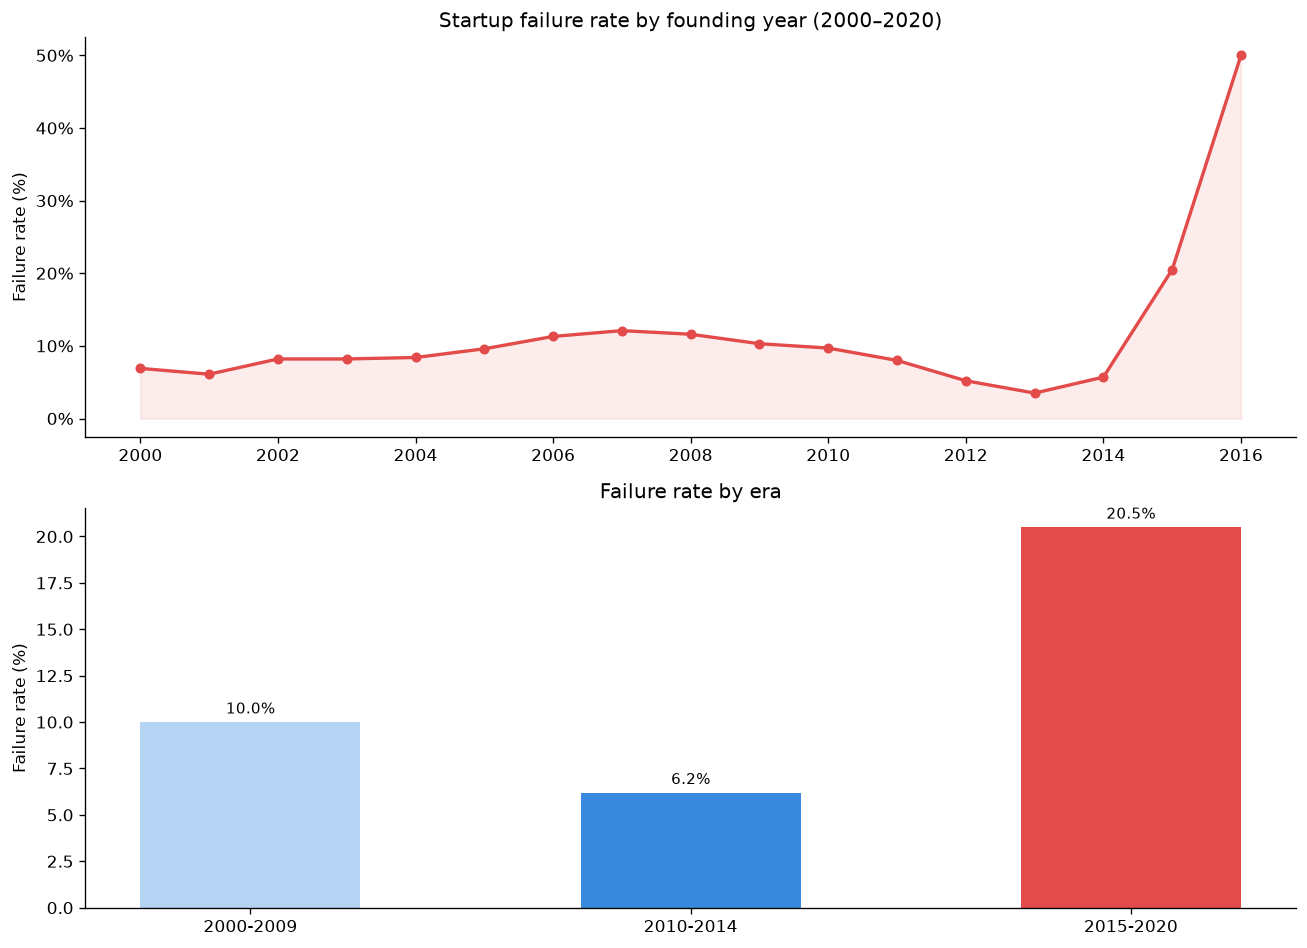

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

# Top: line chart — failure rate by founding year
ax1.plot(year_stats.index, year_stats['failure_pct'],
        color='#E24B4A', marker='o', lw=2, ms=5)
ax1.fill_between(year_stats.index, year_stats['failure_pct'], alpha=0.1, color='#E24B4A')
ax1.set_title('Startup failure rate by founding year (2000–2020)', fontsize=12)
ax1.set_ylabel('Failure rate (%)')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())

# Bottom: failure count by era
era_fail = (df_dated[df_dated['era'].notna()]
            .groupby('era', observed=True)['is_failed']
            .agg(['sum','mean']))
era_fail['failure_pct'] = (era_fail['mean']*100).round(1)
bars = ax2.bar(era_fail.index.astype(str), era_fail['failure_pct'],
              color=['#B5D4F4','#378ADD','#E24B4A','#A32D2D'], width=0.5)
ax2.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax2.set_title('Failure rate by era', fontsize=12)
ax2.set_ylabel('Failure rate (%)')
plt.tight_layout()
plt.savefig('../reports/q7_era_trend.png', dpi=150)
plt.show()
